# Modal analysis of a planar cantilever beam

This example computes the natural frequencies and mode shapes of a 2-D cantilever beam
using `Planar.solve_modes()`.


In [1]:
import matplotlib.pyplot as plt
import torch

from torchfem import Planar
from torchfem.materials import IsotropicElasticityPlaneStress
from torchfem.mesh import rect_quad

torch.set_default_dtype(torch.float64)

## Model setup

We build a cantilever beam with length $L = 10$, height $H = 1$, and unit thickness,
clamped at the left end.


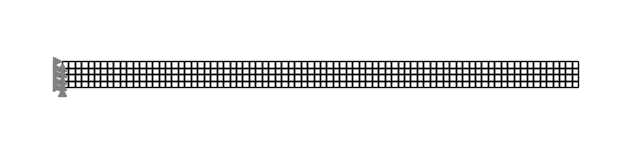

In [2]:
# Geometric parameters
L = 10.0
H = 0.5

# Material parameters
E = 1000.0
nu = 0.3
rho = 1.0

# Build model
material = IsotropicElasticityPlaneStress(E=E, nu=nu, rho=rho)
nodes, elements = rect_quad(81, 5, L, H)

model = Planar(nodes, elements, material, thickness=H)
left = nodes[:, 0] == 0.0
model.constraints[left, :] = True

model.plot()

## Modal analysis

Solve for the first four natural frequencies and mode shapes.


In [3]:
N = 4
omega_sq, modes = model.solve_modes(n_modes=N)

## Comparison with ABAQUS reference

For fair comparison, the ABAQUS reference simulation was performed with CPS4 elements. Fully integrated quads introduce shear locking overestimating the stiffness of the bending modes. 


In [4]:
# ABAQUS reference values for the first 4 modes
omega_ref = [0.0264721, 1.0157, 7.6832, 24.71]

header = f"{'Mode':>4}  {'ω² (torch-fem)':>10}  {'ω² (ABAQUS)':>10}"
print(header)
print("-" * len(header))
for k in range(N):
    fem_val = float(omega_sq[k])
    abq_val = omega_ref[k]
    print(f"{k+1:>4}  {fem_val:>10.4f}  {abq_val:>10.4f}")

Mode  ω² (torch-fem)  ω² (ABAQUS)
---------------------------------
   1      0.0265      0.0265
   2      1.0174      1.0157
   3      7.7127      7.6832
   4     24.7120     24.7100


## Visualise mode shapes


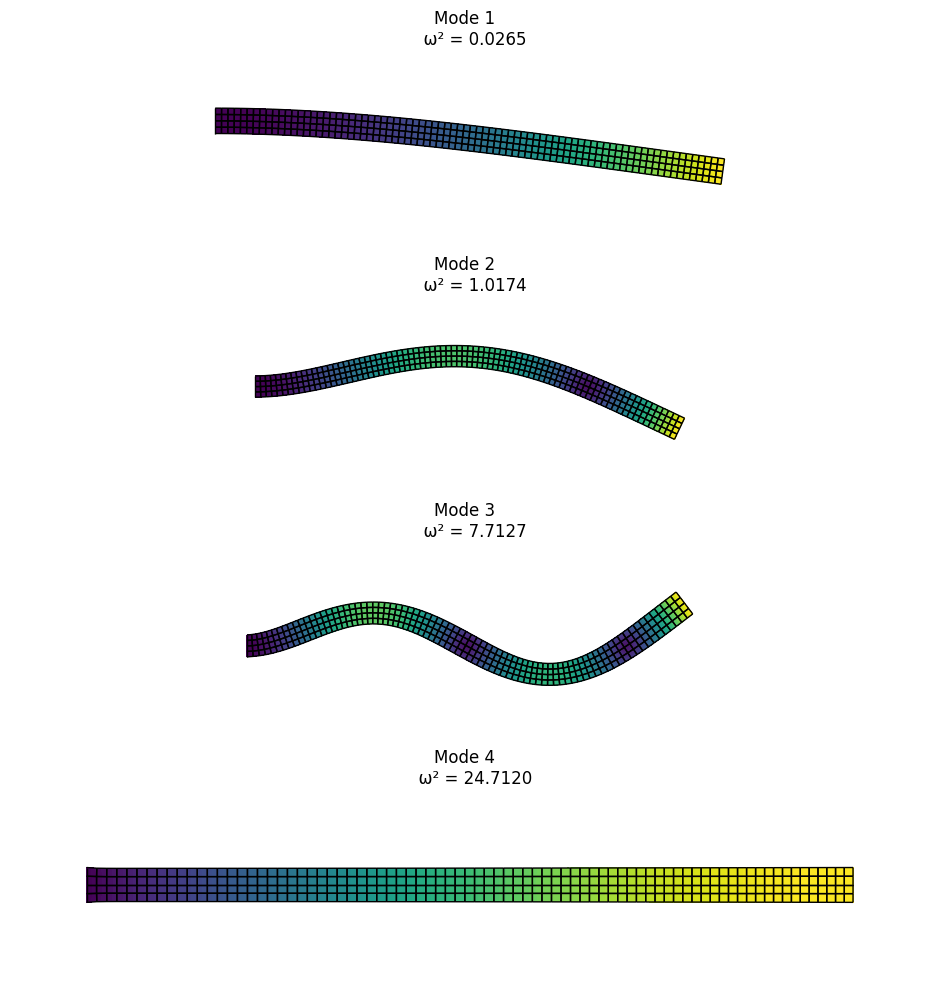

In [5]:
fig, axes = plt.subplots(N, 1, figsize=(10, 10))
for k in range(N):
    mode_k = modes[k]
    # Normalise each mode
    max_mag = torch.norm(mode_k, dim=1).max()
    u_plot = mode_k / max_mag
    model.plot(
        u=u_plot,
        node_property=torch.norm(u_plot, dim=1),
        ax=axes[k],
        bcs=False,
        colorbar=False,
    )
    axes[k].set_title(f"Mode {k + 1}  \n  ω² = {float(omega_sq[k]):.4f}")

plt.tight_layout()
plt.show()